# Dataset physics

Characterization of the 2D forced Navier–Stokes DNS used throughout the paper: a representative vorticity field, the enstrophy spectrum with spectral zoning, band-pass fields per zone, and the flow/dataset parameters (Table 1).

Run from `physics/`. Requires `data/trajectory_real.npy` at the repository root.

In [1]:
import os, sys, random
import warnings
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from matplotlib.colors import LinearSegmentedColormap
warnings.filterwarnings("ignore")

sys.path.append("..")   # repository root
from compression.spectral import bandpass, isotropic_spectrum

## Configuration

In [2]:
DATA_PATH  = "../data/trajectory_real.npy"
SAVE_DIR   = "../results/physics"
os.makedirs(SAVE_DIR, exist_ok=True)

SEED       = 225
k_dealias  = 85
N_SPECTRA  = 500
SPEC_BATCH = 16
FS         = 13

# Simulation parameters (jax-cfd run)
NU            = 1e-3     # kinematic viscosity
K_F           = 4        # forcing wavenumber
GRID_N        = 256
DT_SOLVE      = 5e-4     # solver time step
SAVE_EVERY    = 200      # solver steps between stored snapshots
SNAPSHOT_DT   = DT_SOLVE * SAVE_EVERY   # = 0.1
N_SPINUP      = 1000     # discarded transient snapshots
N_TRAIN       = 4500
N_TEST        = 500

# Spectral zones
ZONES = {
    "inertial": dict(k_lo=5,  k_hi=40, label="IR", color="#2ca02c"),
    "mid":      dict(k_lo=40, k_hi=65, label="DO", color="#e67e00"),
    "high_k":   dict(k_lo=65, k_hi=85, label="DD", color="#9b0000"),
}

# Colormaps
cmap_full = sns.color_palette("icefire", as_cmap=True)
cmap_hk   = LinearSegmentedColormap.from_list("rbc", [(0,0,1),(1,1,1),(1,0,0)])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data

In [3]:
data      = np.load(DATA_PATH)
train_raw = data[N_SPINUP:N_SPINUP + N_TRAIN]
test_raw  = data[N_SPINUP + N_TRAIN:N_SPINUP + N_TRAIN + N_TEST]
mu, sigma = train_raw.mean(), train_raw.std()
test_norm = (test_raw - mu) / (sigma + 1e-9)
print(f"data {data.shape}   train {train_raw.shape}   test {test_raw.shape}")

data (6000, 256, 256)   train (4500, 256, 256)   test (500, 256, 256)


## Fig. 1a — vorticity snapshot

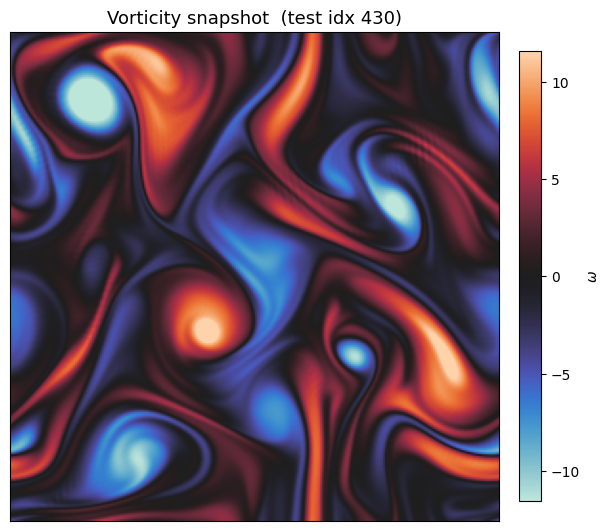

Saved fig1a_vorticity_snapshot.png


In [4]:
rng          = np.random.default_rng(SEED)
idx          = rng.integers(0, len(test_raw))
sample_field = test_raw[idx]

vmax = np.percentile(np.abs(sample_field), 99)
fig_a, ax_a = plt.subplots(1, 1, figsize=(6, 5.5), constrained_layout=True)
im = ax_a.imshow(sample_field, cmap=cmap_full, vmin=-vmax, vmax=vmax, origin="lower")
plt.colorbar(im, ax=ax_a, label=r"$\omega$", fraction=0.046, pad=0.04)
ax_a.set_title(f"Vorticity snapshot  (test idx {idx})", fontsize=FS)
ax_a.set_xticks([]); ax_a.set_yticks([])
plt.savefig(f"{SAVE_DIR}/fig1a_vorticity_snapshot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig1a_vorticity_snapshot.png")

## True-field spectra

In [5]:
spec_loader = DataLoader(
    TensorDataset(torch.tensor(test_norm[:N_SPECTRA, None], dtype=torch.float32)),
    batch_size=SPEC_BATCH, shuffle=False)

all_spectra = {"true": []}
print(f"Computing spectra for {N_SPECTRA} fields ...")
with torch.no_grad():
    for (xb,) in spec_loader:
        xb    = xb.to(device)
        xt_np = xb[:, 0].cpu().numpy() * sigma + mu
        for i in range(xb.size(0)):
            Ei, k_arr = isotropic_spectrum(xt_np[i])
            all_spectra["true"].append(Ei)
print("Done.")

Computing spectra for 500 fields ...
Done.


## Fig. 1b — enstrophy spectrum

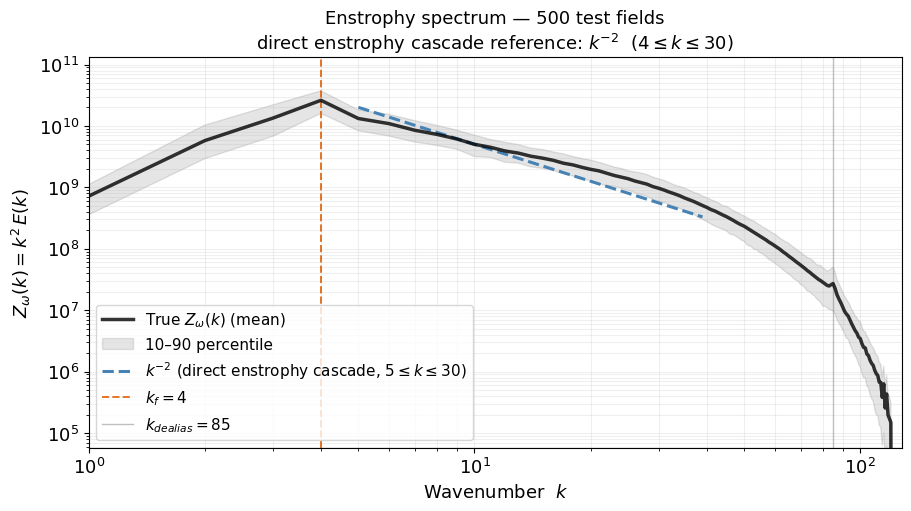

Saved fig1b_enstrophy_spectrum.png


In [6]:
k2         = k_arr ** 2
Zt         = all_spectra["true"] * k2[None, :]          # Z(k) = k^2 E(k)
k_max_plot = 128

# k^{-2} reference anchored at k=10, drawn over 5 <= k < 40
k_ref2        = 10
Z_ref2        = np.interp(k_ref2, k_arr, Zt.mean(0))
k_1           = Z_ref2 * (k_arr / k_ref2) ** (-2.0)
k_direct_mask = (k_arr >= 5) & (k_arr < 40)

mask = k_arr <= k_max_plot
y_lo = np.percentile(Zt[:, mask], 10) * 0.3
y_hi = Zt[:, mask].mean(0).max() * 5

fig_b, ax_b = plt.subplots(1, 1, figsize=(9, 5), constrained_layout=True)
ax_b.loglog(k_arr, Zt.mean(0), color="black", lw=2.5,
            label=r"True $Z_\omega(k)$ (mean)", zorder=5, alpha=0.8)
ax_b.fill_between(k_arr, np.percentile(Zt, 10, axis=0), np.percentile(Zt, 90, axis=0),
                  color="black", alpha=0.10, label="10–90 percentile")
ax_b.loglog(k_arr[k_direct_mask], k_1[k_direct_mask], color="steelblue", lw=2.2, ls="--",
            label=r"$k^{-2}$ (direct enstrophy cascade, $5 \leq k \leq 30$)")
# k^{+1/3} intentionally omitted: inverse range (k<4) too narrow to develop
ax_b.axvline(K_F,       color="#e05c00", lw=1.4, ls="--", alpha=0.85, label=r"$k_f = 4$")
ax_b.axvline(k_dealias, color="gray",    lw=1.0, ls="-",  alpha=0.5, label=rf"$k_{{dealias}}={k_dealias}$")

ax_b.set_xlim(1, k_max_plot)
ax_b.set_ylim(y_lo, y_hi)
ax_b.set_xlabel("Wavenumber  $k$", fontsize=FS)
ax_b.set_ylabel(r"$Z_\omega(k) = k^2\,E(k)$", fontsize=FS)
ax_b.set_title(f"Enstrophy spectrum — {N_SPECTRA} test fields\n"
               r"direct enstrophy cascade reference: $k^{-2}$  ($4 \leq k \leq 30$)", fontsize=FS)
ax_b.tick_params(axis="both", labelsize=13)
ax_b.grid(True, which="both", alpha=0.2)
ax_b.legend(fontsize=11, loc="lower left")
plt.savefig(f"{SAVE_DIR}/fig1b_enstrophy_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig1b_enstrophy_spectrum.png")

## Fig. 1 (paper) — ensemble spectra with spectral zones

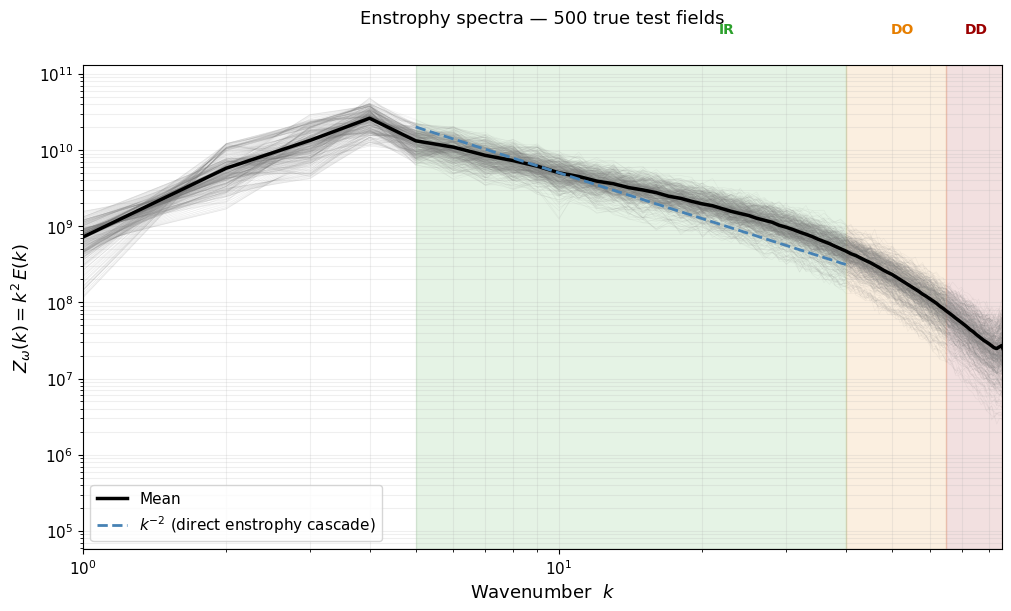

Saved figA_true_spectra.png


In [7]:
N_SPEC  = 500
Zt_all  = all_spectra["true"] * k2[None, :]          # (N_SPEC, n_k)
Zt_mean = Zt_all.mean(0)

# k^{-2} reference anchored inside IR, drawn over 5 <= k <= 40
k_ref_ir = 10
Z_ref_ir = np.interp(k_ref_ir, k_arr, Zt_mean)
k_1_ir   = Z_ref_ir * (k_arr / k_ref_ir) ** (-2.0)
ir_mask  = (k_arr >= 5) & (k_arr <= 40)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
for i in range(N_SPEC):
    ax.loglog(k_arr, Zt_all[i], color="gray", lw=0.4, alpha=0.10)
ax.loglog(k_arr, Zt_mean, color="black", lw=2.5, label="Mean", zorder=5)
ax.loglog(k_arr[ir_mask], k_1_ir[ir_mask], color="steelblue", lw=2.0, ls="--", zorder=10,
          label=r"$k^{-2}$ (direct enstrophy cascade)")

for z in ZONES.values():
    ax.axvspan(z["k_lo"], z["k_hi"], alpha=0.12, color=z["color"], zorder=0)
    ax.text((z["k_lo"] + z["k_hi"]) / 2, 1.06, z["label"], transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=10, color=z["color"], fontweight="bold")

ax.set_xlim(1, k_dealias)
ax.set_ylim(np.percentile(Zt_all, 10) * 0.3, Zt_mean.max() * 5)
ax.set_xlabel("Wavenumber  $k$", fontsize=13)
ax.set_ylabel(r"$Z_\omega(k) = k^2\,E(k)$", fontsize=13)
ax.set_title(f"Enstrophy spectra — {N_SPEC} true test fields", fontsize=13, pad=30)
ax.tick_params(labelsize=11)
ax.grid(True, which="both", alpha=0.2)
ax.legend(fontsize=11)
plt.savefig(f"{SAVE_DIR}/figA_true_spectra.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figA_true_spectra.png")

## Fig. 1 (paper) — band-pass fields per zone

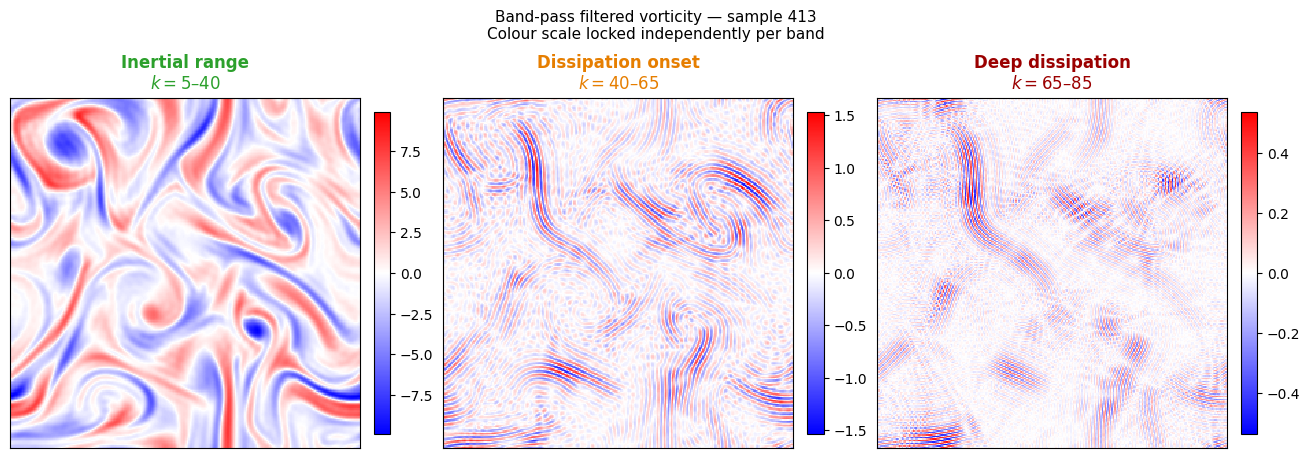

Saved figB_bandpass_zones.png


In [8]:
idx   = random.sample(range(len(test_norm)), 1)
field = sample_field   # (H, W), physical units

bands = {key: bandpass(field, z["k_lo"], z["k_hi"]) for key, z in ZONES.items()}
titles = {
    "inertial": f"Inertial range\n$k = {ZONES['inertial']['k_lo']}$–${ZONES['inertial']['k_hi']}$",
    "mid":      f"Dissipation onset\n$k = {ZONES['mid']['k_lo']}$–${ZONES['mid']['k_hi']}$",
    "high_k":   f"Deep dissipation\n$k = {ZONES['high_k']['k_lo']}$–${ZONES['high_k']['k_hi']}$",
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), constrained_layout=True)
for ax, (key, bfield) in zip(axes, bands.items()):
    vlim = np.abs(bfield).max()
    im = ax.imshow(bfield, cmap=cmap_hk, vmin=-vlim, vmax=vlim, origin="lower", interpolation="none")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set(xticks=[], yticks=[])
    ax.set_title(titles[key], fontsize=12, fontweight="bold", color=ZONES[key]["color"], pad=7)

fig.suptitle(f"Band-pass filtered vorticity — sample {idx[0]}\n"
             "Colour scale locked independently per band", fontsize=11)
plt.savefig(f"{SAVE_DIR}/figB_bandpass_zones.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figB_bandpass_zones.png")

## Flow parameters

Velocity is recovered from vorticity through the stream function: $\hat\psi = -\hat\omega/k^2$, $u = \partial_y\psi$, $v = -\partial_x\psi$.

In [9]:
N = GRID_N
kx = np.fft.rfftfreq(N) * N
ky = np.fft.fftfreq(N)  * N
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
K2[0, 0] = 1.0                         # avoid divide by zero at k=0

u_rms_vals = []
for field in train_raw:
    omega_hat = np.fft.rfft2(field)
    psi_hat   = -omega_hat / K2
    u_phys    = np.fft.irfft2( 1j * KY * psi_hat, s=(N, N))
    v_phys    = np.fft.irfft2(-1j * KX * psi_hat, s=(N, N))
    u_rms_vals.append(np.sqrt(np.mean(u_phys**2 + v_phys**2)))

U_rms = np.mean(u_rms_vals)
L_f   = 2 * np.pi / K_F
Re_f  = U_rms * L_f / NU
tau_f = L_f / U_rms

print(f"u_rms = {U_rms:.4f}")
print(f"L_f   = {L_f:.4f}")
print(f"Re_f  = {Re_f:.1f}")
print(f"tau_f = {tau_f:.4f} time units")
print(f"Test set spans   {N_TEST  * SNAPSHOT_DT / tau_f:.0f} eddy turnover times - forcing turn-over")
print(f"Train set spans  {N_TRAIN * SNAPSHOT_DT / tau_f:.0f} eddy turnover times - forcing turn-over")

u_rms = 1.4321
L_f   = 1.5708
Re_f  = 2249.6
tau_f = 1.0968 time units
Test set spans   46 eddy turnover times - forcing turn-over
Train set spans  410 eddy turnover times - forcing turn-over


## Table 1 — flow configuration, discretization, and dataset

In [10]:
from IPython.display import Markdown, display

k_max   = GRID_N // 3            # 2/3 dealiasing
T_total = len(data) * SNAPSHOT_DT
to_tau  = lambda n: n * SNAPSHOT_DT / tau_f

def sci(x):
    e = int(np.floor(np.log10(abs(x)))); m = x / 10**e
    return rf"$10^{{{e}}}$" if np.isclose(m, 1) else rf"${m:.3g}\times10^{{{e}}}$"

sections = [
    ("Flow configuration", [
        (r"Viscosity $\nu$",                                  sci(NU)),
        (r"Forcing wavenumber $k_f$",                         rf"${K_F}$"),
        (r"Forcing scale $L_f = 2\pi/k_f$",                   rf"${L_f:.2f}$"),
        (r"RMS velocity $u_{\mathrm{rms}}$",                  rf"${U_rms:.2f}$"),
        (r"Reynolds number $Re_f = u_{\mathrm{rms}}L_f/\nu$", sci(float(f"{Re_f:.3g}"))),
        (r"Turnover time $\tau_f = L_f/u_{\mathrm{rms}}$",    rf"${tau_f:.2f}$"),
    ]),
    ("Discretization", [
        (r"Grid",                                  rf"${GRID_N}^2$"),
        (r"Dealiasing cutoff $k_{\max}$",          rf"${k_max}$"),
        (r"Scale separation $k_{\max}/k_f$",       rf"${k_max / K_F:.0f}$"),
        (r"Time step $\Delta t_{\mathrm{solve}}$", sci(DT_SOLVE)),
    ]),
    ("Dataset", [
        (r"Total integration time", rf"${T_total:.0f}$ (${T_total / tau_f:.0f}\,\tau_f$)"),
        (r"Snapshot interval",      rf"${SNAPSHOT_DT:.1f}$ (${SNAPSHOT_DT / tau_f:.2f}\,\tau_f$)"),
        (r"Discarded spin-up",      rf"${N_SPINUP}$ fields (${to_tau(N_SPINUP):.0f}\,\tau_f$)"),
        (r"Training set",           rf"${N_TRAIN}$ fields (${to_tau(N_TRAIN):.0f}\,\tau_f$)"),
        (r"Test set",               rf"${N_TEST}$ fields (${to_tau(N_TEST):.0f}\,\tau_f$)"),
    ]),
]

# Rendered table in the notebook
md = ["| Quantity | Value |", "|:--|--:|"]
for title, rows in sections:
    md.append(f"| ***{title}*** | |")
    md += [f"| {name} | {val} |" for name, val in rows]
display(Markdown("\n".join(md)))

# LaTeX table for the paper
lines = [r"\begin{table}[t]", r"\centering", r"\small",
         r"\caption{Flow configuration, discretization, and dataset composition.}",
         r"\label{tab:dataset}", r"\begin{tabular}{@{}lr@{}}", r"\toprule"]
for i, (title, rows) in enumerate(sections):
    if i > 0:
        lines.append(r"\midrule")
    lines.append(rf"\multicolumn{{2}}{{@{{}}l}}{{\textit{{{title}}}}}\\")
    lines += [rf"{name:<52s} & {val} \\" for name, val in rows]
lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]

with open(f"{SAVE_DIR}/table_dataset.tex", "w") as f:
    f.write("\n".join(lines))
print(f"Saved {SAVE_DIR}/table_dataset.tex")

| Quantity | Value |
|:--|--:|
| ***Flow configuration*** | |
| Viscosity $\nu$ | $10^{-3}$ |
| Forcing wavenumber $k_f$ | $4$ |
| Forcing scale $L_f = 2\pi/k_f$ | $1.57$ |
| RMS velocity $u_{\mathrm{rms}}$ | $1.43$ |
| Reynolds number $Re_f = u_{\mathrm{rms}}L_f/\nu$ | $2.25\times10^{3}$ |
| Turnover time $\tau_f = L_f/u_{\mathrm{rms}}$ | $1.10$ |
| ***Discretization*** | |
| Grid | $256^2$ |
| Dealiasing cutoff $k_{\max}$ | $85$ |
| Scale separation $k_{\max}/k_f$ | $21$ |
| Time step $\Delta t_{\mathrm{solve}}$ | $5\times10^{-4}$ |
| ***Dataset*** | |
| Total integration time | $600$ ($547\,\tau_f$) |
| Snapshot interval | $0.1$ ($0.09\,\tau_f$) |
| Discarded spin-up | $1000$ fields ($91\,\tau_f$) |
| Training set | $4500$ fields ($410\,\tau_f$) |
| Test set | $500$ fields ($46\,\tau_f$) |

Saved ../results/physics/table_dataset.tex
